# VMT Reduction Feasibility Analysis

The purpose of this script is to define a set of rules that classify which trips in the TBI could feasibly swith to another mode.  The result of this analysis will be a set of binary flags attached to each TBI record where the mode is car:

    feasible_walk_shift    - it is feasible for the trip to switch to walk
    feasible_bike_shift    - it is feasible for the trip to switch to bike
    feasible_transit_shift - it is feasible for the trip to switch to transit
    feasible_shift         - it is feasible for the trip to switch to any non-car mode

In all cases, the flag starts as 1 (feasible) and we set it to infeasible if it violates one or more of our rules.  Even though our interst is in understanding which car trips could switch to another mode, we code this flag for all modes.  This way, we can see how existing trips on that mode violate the feasibility rules.  In general, we aim to follow the "95% rule" such that 95% of trips that currently use that mode meet the feasibility condition.  Therefore, about 5% of trips will violate our own rules.  This is ok, because these trips are the most dedicated users of that mode, and new users will likely be less dedicated.  

The list below shows several of the factors we wish to test.  

### Definition of what is a feasible mode shift

- Trip duration, and the difference in duration between the auto trip and non-driving mode (see Optional Task A for a proposal of a more detailed exploration of time constraints).
- Trip distance
- Season or Weather15
- Whether the trip occurred during daylight hours16
- Number of passengers or children on trip17
- Traveler’s age, disability status, whether or not they drive
- Cargo carrying needs: Though not recorded by the survey, the detailed “trip purpose” variable in the survey includes trips to get groceries or shop for a large item.
- Elevation change (hills on bicycle trips), calculated from the re-routing analysis
- Percent of trip made on higher Level of traffic stress routes (biking, walking), calculated from re-routing analysis
- Other measures of walkability and safety garnered during the re-routing analysis

### More to consider:
- Walk distance > X miles
- Bike distance > X miles
- More than two transfers on transit
- No transit path found
- Transit walking distance for a specific leg > X miles

#### More to consider
- Walk: Generalized cost > X
    -    Distance on QOS 1 > X or % of trip on QOS 1 > X
    -    Distance on QOS 2 > X or % of trip on QOS 1 > X
- Bike: Generalized cost > X
    -    Distance on LTS 4 > X or % of trip on LTS 4 > X
    -    Distance on LTS 3 > X or % of trip on LTS 3 > X
- Transit: Time > X

#### Conflicts with other trips:
- Work and School are always assumed to be fixed. 
- Dropping off or pickup kids is assumed to be fixed
- On the way to work/school/kid pudo arrival time is held constant, and re-calculate the departure time 
  based on the travel time of the alternate mode. If that departure time is earlier than the arrival time 
  of the previous trip, then we consider it to be an infeasible switc
- On the way home from work/school/kid pudo, departure time is held constatn.  Recalculate the arrival time
  based on teh travel time of the alternative mode.  If that arrival time is later than the departure time
  of the next trip, tehn we consider it to be an infeasible switch. 

## Read and merge data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [4]:
import math
import keyring
import itertools
from ast import literal_eval

In [31]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [5]:
%%html
<style>
.rendered_html p {
    font-size: 12px;
    font-family: Times New Roman, serif;
    text-align:justify}
</style>

In [6]:
# This is used to avoid hard-coding directories. 
# To set the directory, use the command prompt or a notebook you don't check in.  run:
# import keyring
# keyring.set_password("msp", "vmt_reduction_dir", <directory>)

# get base path for data
data_dir = keyring.get_password("msp", "vmt_reduction_dir")

In [41]:
# read in the data
df = pd.read_csv(data_dir + "/data_processed/tbi_cleaned.csv")

C:\Users\ger225\.conda\envs\gis\lib\site-packages\IPython\core\interactiveshell.py:3155: DtypeWarning: Columns (33,34,35,52,64,65,66,67,68,69,70) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [23]:
# # read path geopkg data
car = gpd.read_file(data_dir + "/Data_Processed/car_trips.gpkg")
bike = gpd.read_file(data_dir + "/Data_Processed/bike_lts.gpkg")
transit = gpd.read_file(data_dir + "/Data_Processed/transit-trips.gpkg")
walk = gpd.read_file(data_dir + "/Data_Processed/walk_trips.gpkg")

C:\Users\ger225\.conda\envs\gis\lib\site-packages\geopandas\geodataframe.py:422: RuntimeWarning: Sequential read of iterator was interrupted. Resetting iterator. This can negatively impact the performance.
  for feature in features_lst:


In [24]:
# calculate duration from star/tend times
transit["start_time_dt"] = pd.to_datetime(transit["start_time"])
transit["end_time_dt"] = pd.to_datetime(transit["end_time"])

transit["duration"] = (transit["end_time_dt"] - transit["start_time_dt"]).apply(lambda x: x.seconds / 60)

In [25]:
# create a gdf for linked trips
agg_fns = {
    "trip_id": "first",
    "leg_index": "count",
    "start_time": "first",
    "end_time": "last",
    "origin_stop_id": "first", # throw away
    "origin_stop_name": "first",
    "destination_stop_id": "first",
    "destination_stop_name": "first",
    "route_id": "first", 
    "route_short_name": "first",
    "route_long_name": "first",
    "route_type": "first", 
    "leg_type": "first", # end throw away
    "start_time_dt": "first",
    "end_time_dt": "last",
    "duration": "sum"
}

transit_grouped = transit.dissolve(by="trip_id", aggfunc=agg_fns) # merges geometries in addition to aggregating the rest of the columns

In [40]:
# rename columns to distinguish by mode
def add_mode_to_column_name(df, mode_name): 
    renames = {}
    for col in df.columns:
        renames[col] = mode_name + '_' + col
    return df.rename(columns = renames)

car = add_mode_to_column_name(car, 'car')
walk = add_mode_to_column_name(walk, 'walk')
bike = add_mode_to_column_name(bike, 'bike')
transit = add_mode_to_column_name(transit_grouped, 'transit')


In [42]:
# merge TBI records with routes into a single dataframe
df = gpd.GeoDataFrame(df)
df = df.merge(car, left_on='trip_id', right_on='car_trip_id', how='left')
df = df.merge(walk, left_on='trip_id', right_on='walk_trip_id', how='left')
df = df.merge(bike, left_on='trip_id', right_on='bike_trip_id', how='left')
df = df.merge(transit, left_on='trip_id', right_on='transit_trip_id', how='left')

In [135]:
# to start, everyone is allowed to do everything
df['feasible_walk_shift'] = True
df['feasible_bike_shift'] = True
df['feasible_transit_shift'] = True
df['feasible_shift'] = True

In [105]:
# currently ignore schools bus and taxi/ridehail/carshare -- can decide whether to omit or group with others later
# with school buses, we might need analysis for school-age children only since school buses aren't a widely available mode to the public, omit for now
# with taxi/ridehail/carshare, could be transit but it is very distinct,  omit for now
valid_modes = [("Car","distance"), 
               ("Bike/Scooter","distance"), 
               ("Walk","distance"), 
               ("Transit","distance")]

In [47]:
def plot_density(column: pd.Series, percentile=0.95, discrete=False, bins=100, size=(12, 6)):
    fig, ax = plt.subplots(figsize=size)
    sns.histplot(column, ax=ax, discrete=discrete, bins=bins, kde=True, stat="density")
    val = column.quantile(q=percentile)
    plt.axvline(x=val, color="red")
    return fig, ax

In [111]:
def plot_mode_density(df: pd.DataFrame, modes=valid_modes, percentile=0.95, size=(12, 6), bins=300, function=lambda x: x):
    palette = itertools.cycle(sns.color_palette()) # cycle through colors to make sure each mode gets a unique one
    fig, ax = plt.subplots(figsize=size)
    for m in modes: # cycle through all modes
        mode = m[0]
        column = m[1]
        label = mode + ' ' + column
        
        c = next(palette) # get color to use
        group = df[df["mode"] == mode] # filter out the current mode
        sns.histplot(function(group[column]), ax=ax, stat="density", kde=True, label=label, color=c, bins=bins) # plot hist plot with kde overlayed in the color
        val = function(group[column]).quantile(q=percentile) # calculate the value of the given percentile (default 0.95)
        plt.axvline(x=val, color=c) # plot line representing that value on the plot        
        plt.legend()
    return fig, ax

In [117]:
def show_summaries(df: pd.DataFrame, modes=valid_modes, percentile=0.95): # show normal summaries for each mode side by side
    res = []
    labels = []
    p = [0.25, 0.5, 0.75]
    p.append(percentile)
    for m in modes:        
        mode = m[0]
        column = m[1]
        labels.append(mode + ' ' + column)
        
        group = df[df["mode"] == mode]
        res.append(group[column].describe(percentiles=p))
    x = pd.concat(res, axis=1)
    x.columns = labels
    return x

In [60]:
df.describe()

,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,duration,distance,speed_mph,vehicle_trips,vmt,o_lat,o_lon,o_bg_2010,d_lat,d_lon,d_bg_2010,num_unlinked_trips,gas_link,home_lat,home_lon,home_bg_2010,num_adults,num_kids,num_students,num_workers,hh_weight,person_weight,day_weight,trip_weight,car_duration_seconds,car_distance_meters,car_weight,walk_duration_seconds,walk_distance_meters,walk_weight,bike_duration_seconds,bike_distance_meters,bike_weight,bike_distance_meters_1,bike_distance_meters_2,bike_distance_meters_3,bike_distance_meters_4,transit_leg_index,transit_route_type,transit_duration,feasible_walk_shift,feasible_bike_shift,feasible_transit_shift,feasible_shift
count,453259.000000,453259.000000,4.532590e+05,4.532590e+05,453259.000000,453259.000000,453259.000000,453259.000000,453259.000000,453259.000000,453259.000000,453259.000000,453259.000000,453259.000000,4.532590e+05,453259.000000,453259.000000,4.532590e+05,453259.000000,453259.000000,453259.000000,453259.000000,4.532590e+05,453259.000000,453259.000000,453259.000000,453259.000000,453259.000000,453259.000000,453259.000000,453259.000000,451953.000000,451953.000000,451953.000000,451954.000000,451954.000000,451954.000000,451954.000000,451954.000000,451954.000000,451954.000000,451954.000000,451954.000000,451954.000000,195752.000000,193480.000000,195752.000000,453259.0,453259.0,453259.0,453259.0
mean,255393.681738,1.336631,1.990523e+07,1.990523e+09,1.684701,3.703673,35849.980722,19.011614,6.256792,0.312943,0.603776,4.297028,44.961241,-93.247269,2.792551e+11,44.961214,-93.247262,2.792740e+11,1.044932,0.018336,44.964395,-93.247361,2.804591e+11,1.840804,0.825096,0.970156,1.465198,225.399247,225.399247,50.298958,57.468036,676.896796,10158.309830,863.296943,6940.224910,9616.157565,6940.224910,7756.469445,14453.269182,4542.896665,13665.707225,258.621857,319.903975,209.017988,4.083422,2.825837,66.000215,1.0,1.0,1.0,1.0
std,147809.335517,0.472558,1.014088e+06,1.014088e+08,1.001631,2.041636,61446.268962,22.367724,8.286667,0.231020,0.383707,6.740487,0.172099,0.247157,4.804677e+10,0.172338,0.247566,4.809931e+10,0.277083,0.134164,0.181755,0.256998,5.121868e+10,0.626477,1.193388,1.254512,0.829950,310.773280,310.773280,146.486038,186.619226,674.321870,13083.871528,1011.823246,9309.383672,12882.346956,9309.383672,9140.086134,19575.354480,5247.320178,18735.384005,738.283615,1011.620884,470.591157,1.396646,0.701311,234.249378,0.0,0.0,0.0,0.0
min,0.000000,1.000000,1.811206e+07,1.811206e+09,1.000000,1.000000,1.000000,0.100000,0.010238,0.001689,0.000000,0.000000,43.651190,-95.008390,2.700305e+11,43.651770,-95.385930,2.700305e+11,1.000000,0.000000,44.197420,-94.541310,2.700305e+11,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.316667,1.0,1.0,1.0,1.0
25%,127314.500000,1.000000,1.921317e+07,1.921317e+09,1.000000,2.000000,11.000000,8.000000,1.168627,0.125302,0.333333,0.439429,44.885630,-93.355760,2.705302e+11,44.885370,-93.355740,2.705302e+11,1.000000,0.000000,44.893980,-93.357200,2.705301e+11,1.000000,0.000000,0.000000,1.000000,48.566070,48.566070,0.000000,0.000000,225.600000,2019.400000,243.600000,1312.200000,1819.325000,1312.200000,2226.200000,2564.600000,1447.600000,2268.092414,0.000000,0.000000,6.079122,3.000000,3.000000,15.500000,1.0,1.0,1.0,1.0
50%,255590.000000,1.000000,1.967055e+07,1.967055e+09,1.000000,4.000000,26.000000,14.000000,3.216066,0.273746,0.500000,1.774540,44.957820,-93.250860,2.705310e+11,44.957680,-93.250820,2.705310e+11,1.000000,0.000000,44.957620,-93.251420,2.705310e+11,2.000000,0.000000,0.000000,2.000000,52.133690,52.133690,1.744919,1.744919,469.200000,5382.700000,511.700000,3574.200000,4956.400000,3574.200000,4720.400000,7378.250000,2921.100000,6869.985963,20.149948,23.580548,80.300582,3.000000,3.000000,24.966667,1.0,1.0,1.0,1.0
75%,383697.500000,2.000000,2.108360e+07,2.108360e+09,2.000000,5.000

## 1. Walk distance > X miles

Walk trips are generally short.  Here we consider the trip length distribution of walking trips, and set a maximum allowable distance to be considered feasible to walk. 

(0.0, 10.0)

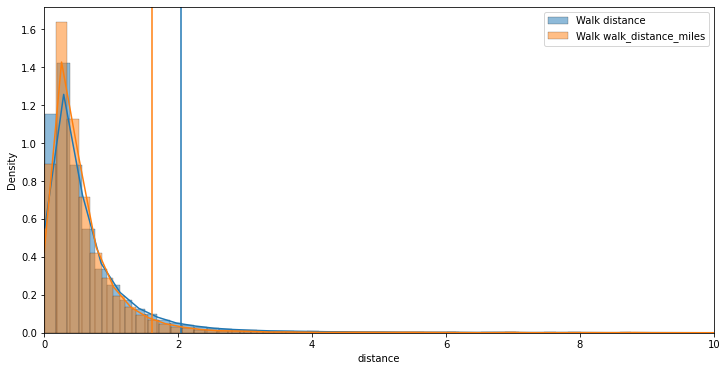

In [113]:
# check how the calculated walk distance compares to observed for walk trips
df['walk_distance_miles'] = df['walk_distance_meters'] / 1609.34
fig, ax = plot_mode_density(df, [('Walk','distance'), ('Walk','walk_distance_miles')]) 
ax.set_xlim(left=0, right=10) # cutoff upper end, there are some outliers that make the graph hard to read

(0.0, 25.0)

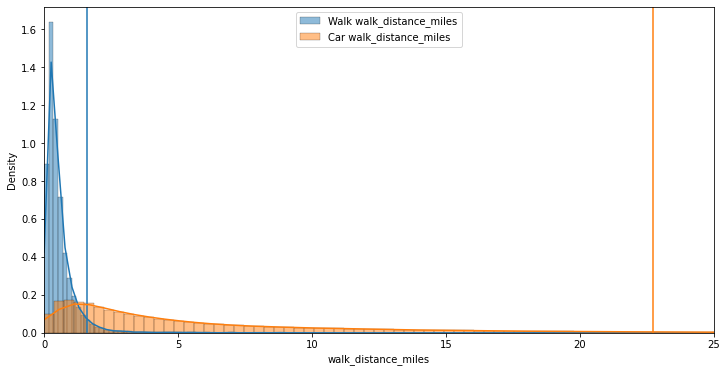

In [116]:
# compare those choosing walk to those driving
df['walk_distance_miles'] = df['walk_distance_meters'] / 1609.34
fig, ax = plot_mode_density(df, [('Walk','walk_distance_miles'), ('Car','walk_distance_miles')]) 
ax.set_xlim(left=0, right=25) # cutoff upper end, there are some outliers that make the graph hard to read

In [119]:
show_summaries(df, modes=[('Walk','walk_distance_miles'), ('Car','walk_distance_miles')])

,Walk walk_distance_miles,Car walk_distance_miles
count,49638.000000,377855.000000
mean,0.609532,6.766000
std,0.992187,8.363825
min,0.000000,0.000000
25%,0.228665,1.625014
50%,0.393329,3.783104
75%,0.685063,8.685703
95%,1.604847,22.744417
max,51.582388,111.875862


In [140]:
# set the maximum feasible walking distance to 1.6 miles
percent_before = len(df[(df['mode']=='Car') & (df['feasible_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to walk.")

df.loc[df['walk_distance_miles'] > 1.6, 'feasible_walk_shift'] = False

percent_before = len(df[(df['mode']=='Car') & (df['feasible_walk_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_before , " percent of car trips could shift to walk.")


Before constraint  24.84826904055391  percent of car trips could shift to walk.
After constraint  24.84826904055391  percent of car trips could shift to walk.


## 2. Bike distance > X miles

Bike trips are generally short.  Here we consider the trip length distribution of walking trips, and set a maximum allowable distance to be considered feasible to walk. 

(0.0, 25.0)

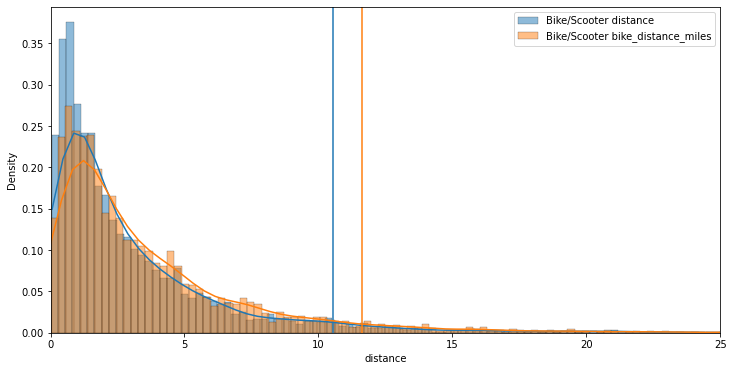

In [145]:
# check how the calculated bike distance compares to observed for bike trips
df['bike_distance_miles'] = df['bike_distance_meters'] / 1609.34
fig, ax = plot_mode_density(df, [('Bike/Scooter','distance'), ('Bike/Scooter','bike_distance_miles')]) 
ax.set_xlim(left=0, right=25) # cutoff upper end, there are some outliers that make the graph hard to read

(0.0, 25.0)

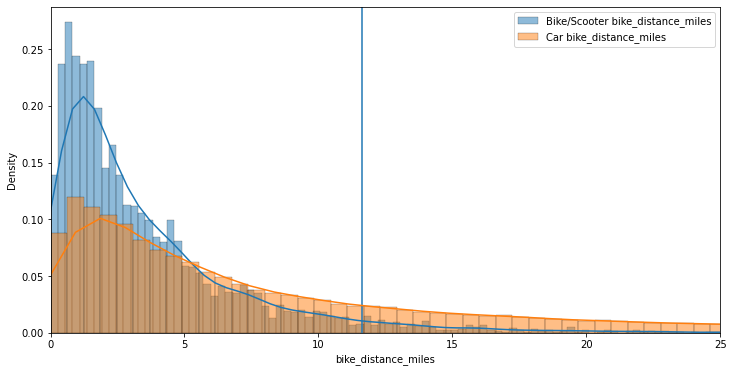

In [144]:
# check how the calculated bike distance compares to observed for bike trips
df['bike_distance_miles'] = df['bike_distance_meters'] / 1609.34
fig, ax = plot_mode_density(df, [('Bike/Scooter','bike_distance_miles'), ('Car','bike_distance_miles')]) 
ax.set_xlim(left=0, right=25) # cutoff upper end, there are some outliers that make the graph hard to read

In [146]:
show_summaries(df, modes=[('Bike/Scooter','bike_distance_miles'), ('Car','bike_distance_miles')])

,Bike/Scooter bike_distance_miles,Car bike_distance_miles
count,7688.000000,377855.000000
mean,3.745105,10.182736
std,4.298949,12.707739
min,0.000000,0.000000
25%,1.122588,2.357612
50%,2.378087,5.619819
75%,4.782162,13.105155
95%,11.625760,34.398182
max,81.547342,184.699753


In [147]:
# set the maximum feasible walking distance to 1.6 miles
percent_before = len(df[(df['mode']=='Car') & (df['feasible_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("Before constraint ", percent_before , " percent of car trips could shift to bike.")

df.loc[df['bike_distance_miles'] > 11.6, 'feasible_bike_shift'] = False

percent_before = len(df[(df['mode']=='Car') & (df['feasible_bike_shift'])]) / len(df[df['mode']=='Car']) * 100
print("After constraint ", percent_before , " percent of car trips could shift to bike.")


Before constraint  100.0  percent of car trips could shift to bike.
After constraint  71.68822947576656  percent of car trips could shift to bike.


## 3. Transit distance to a transit stop

Transit trips are a bit more complicated, because they come in several legs.  For example: 

    Leg 1: Walk to Bus Stop
    Leg 2: Ride Bus to Another Stop
    Leg 3: Walk to Destination
    
Here we consider the maximum walking distance to or from a bus stop.  Here we can treat each walking leg on a transit trip as a separate observation.  